In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

from dateutil.relativedelta import relativedelta

from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX

# from keras.models import Sequential
# from keras.layers import LSTM, Dense

from prophet import Prophet

from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from itables import init_notebook_mode
from itables import show

import constantes as const
from loader import cargar_dataset

In [2]:
columnas_descartables = [
    const.COL_INDICATIVO,
    const.COL_NOMBRE
]

In [3]:
df = cargar_dataset(const.PATH_DF_PROCESADO).drop(columns = columnas_descartables)

In [4]:
display(df.sample(20))

,fecha,provincia,altitud,tmed,prec,tmin,tmax,velmedia,sol,hrMedia,racha,hrMax,hrMin,lon,lat
6329898,2021-08-02,ALICANTE,530,22.8,0.0,17.1,28.5,1.9,<NA>,54.0,6.9,75.0,33.0,-0.46,38.710833
5687622,2019-07-14,SANTA CRUZ DE TENERIFE,735,20.1,0.0,14.3,25.9,<NA>,<NA>,<NA>,<NA>,99.0,33.0,-16.789167,28.233333
4489327,2015-08-27,MALAGA,172,26.1,0.0,19.1,33.1,2.5,<NA>,56.0,8.3,82.0,41.0,-4.696667,36.854722
5302435,2018-04-19,CIUDAD REAL,640,17.2,0.0,10.8,23.6,2.8,<NA>,49.0,10.3,78.0,32.0,-3.215833,39.390833
6813442,2023-02-08,CACERES,425,7.0,0.2,4.2,9.9,7.8,<NA>,81.0,13.9,97.0,69.0,-6.745,39.618056
2044117,2004-06-03,ILLES BALEARS,57,20.9,<NA>,17.9,23.9,6.1,<NA>,71.0,11.9,<NA>,<NA>,3.478056,39.716667
3850048,2013-07-05,AVILA,1012,24.6,0.0,14.9,34.3,3.3,<NA>,38.0,7.8,72.0,26.0,-5.519167,40.355278
6897361,2023-05-15,SALAMANCA,1027,12.3,0.0,5.5,19.1,2.8,<NA>,47.0,8.9,77.0,35.0,-6.223611,40.569444
2653211,2008-12-02,SALAMANCA,817,-0.4,0.0,-6.6,5.8,1.7,<NA>,79.0,6.4,100.0,58.0,-5.779722,40.903611
2594139,2008-07-29,CASTELLON,35,26.2,0.0,23.0,29.5,3.1,<NA>,71.0,7.2,89.0,59.0,0.183611,40.211389


In [5]:
corr = df.drop(columns = [const.COL_PROVINCIA]).corr()

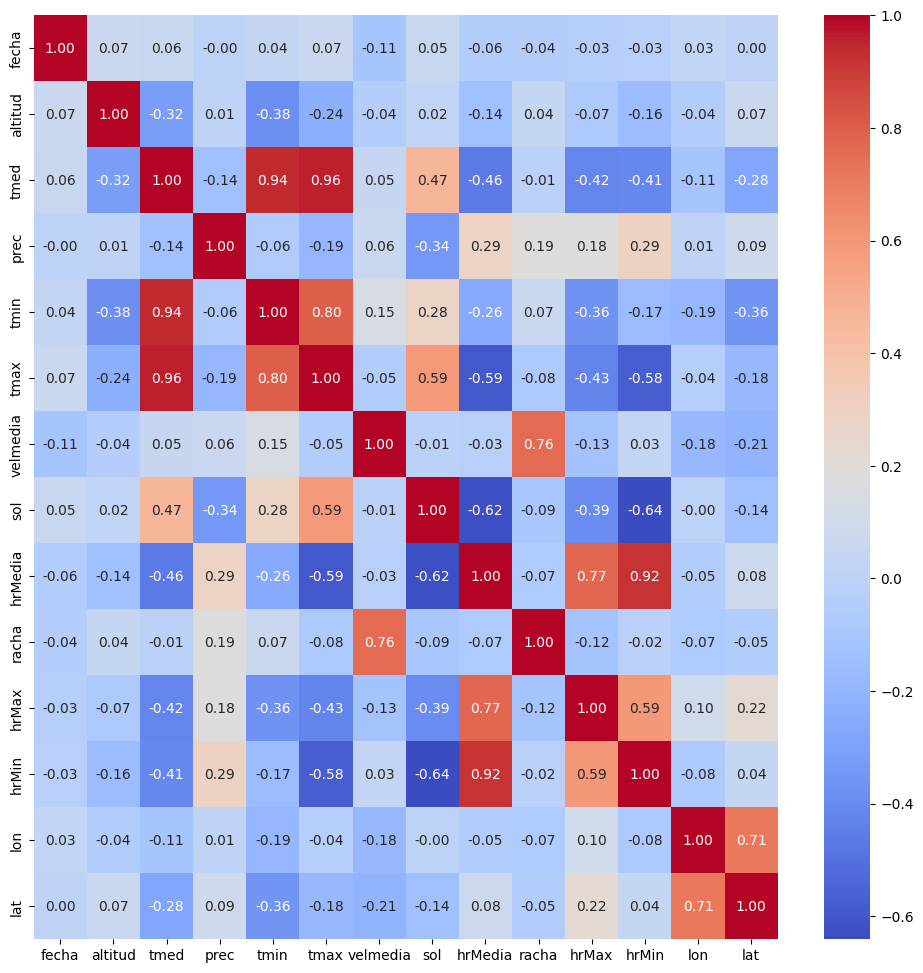

In [6]:
plt.figure(figsize=(12, 12))
sns.heatmap(corr,
            cmap="coolwarm",
            annot=True,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            fmt=".2f")
plt.show()

In [7]:
### Parte experimental###

In [8]:
variables_dependientes = [
                            const.COL_TMAX,
                            const.COL_TMED,
                            const.COL_TMIN,
                            const.COL_PREC,
                            const.COL_RACHA
                        ]

In [9]:
lista_provincias = list(df[const.COL_PROVINCIA].unique())

In [10]:
df_agg = (
    df.set_index(const.COL_FECHA)
      .groupby([pd.Grouper(freq = 'MS'), const.COL_PROVINCIA])
      .agg({
          const.COL_TMAX:'max',
          const.COL_TMED:'mean',
          const.COL_TMIN:'min',
          const.COL_PREC:'sum',
          const.COL_RACHA:'max'
          # const.COL_VELMEDIA: 'mean',
          # const.COL_SOL: 'mean',
          # const.COL_HRMAX: 'max',
          # const.COL_HRMEDIA: 'mean'
          # const.COL_HRMIN: 'min'
      })
    .reset_index()
)

In [11]:
df_agg = (
            df_agg
                .set_index(const.COL_FECHA)
                .groupby(const.COL_PROVINCIA)
                .apply(lambda g: g.asfreq('MS').interpolate(method = 'linear', limit_direction = 'both'))
                .reset_index(level = 0).sort_index()
)

In [12]:
ANNOS_TEST = 10

periodos_test = ANNOS_TEST * 12 * len(lista_provincias)
df_train = df_agg.iloc[:-periodos_test].copy()
df_test = df_agg.iloc[-periodos_test:].copy()

In [13]:
cols_transformer = [const.COL_PREC, const.COL_RACHA]

transformer = PowerTransformer(method = 'yeo-johnson')
df_train[cols_transformer] = transformer.fit_transform(df_train[cols_transformer])
df_test[cols_transformer] = transformer.transform(df_test[cols_transformer])

In [14]:
cols_scaler = df_agg.select_dtypes(include = 'number').columns

scaler = StandardScaler()
# df_agg[cols_scaler] = scaler.fit_transform(df_agg[cols_scaler])
df_train[cols_scaler] = scaler.fit_transform(df_train[cols_scaler])
df_test[cols_scaler] = scaler.transform(df_test[cols_scaler])

In [15]:
df_agg.sample(20)

,provincia,tmax,tmed,tmin,prec,racha
fecha,,,,,,
2001-04-01,MURCIA,31.0,17.14381,4.6,94.7,20.8
1993-01-01,BURGOS,14.7,3.464516,-8.9,6.7,20.8
1974-05-01,CORDOBA,35.0,19.329032,5.0,6.4,6.9
2006-06-01,CUENCA,37.4,21.706667,6.2,190.0,16.4
2004-08-01,LA RIOJA,36.7,21.195161,6.5,150.3,25.8
2022-03-01,ARABA/ALAVA,20.9,8.467384,-2.0,766.6,26.7
2011-08-01,CORDOBA,44.4,26.987042,9.8,19.6,19.2
1998-01-01,ALBACETE,20.7,7.298901,-4.0,85.1,16.9
1977-03-01,VALENCIA,26.2,13.914516,-0.8,19.2,24.4


In [16]:
# ANNOS_TEST = 10
ANNOS_FUTURO = 10

dict_modelos = {}

for provincia in lista_provincias:
    
    df_train_prov = df_train[df_train[const.COL_PROVINCIA] == provincia].drop(columns=[const.COL_PROVINCIA])
    df_test_prov = df_test[df_test[const.COL_PROVINCIA] == provincia].drop(columns=[const.COL_PROVINCIA])

    df_train_prov.index.freq = 'MS'
    df_test_prov.index.freq = 'MS'
    
    # Inicializamos el modelo VAR para la provincia
    model_prov = VAR(df_train_prov)

    # Encontramos el p óptimo
    p = model_prov.select_order(maxlags=60)
    optimal_p = p.selected_orders['aic']
    model_prov_fitted = model_prov.fit(optimal_p)
    
    # Realizamos rolling forecasts para comparar con los valores de test
    history = df_train_prov.values[-model_prov_fitted.k_ar:]  # Últimos lags del training
    prediccion_test = []
    for t in range(len(df_test_prov)):
        # Predecir el próximo paso
        yhat = model_prov_fitted.forecast(history, steps=1)
        prediccion_test.append(yhat[0])
        # Actualizar history con el valor real del test set
        obs = df_test_prov.iloc[t].values
        history = np.vstack([history[1:], obs])  # Deslizar la ventana??

    # Realizamos predicciones a futuro
    periodos_futuro = ANNOS_FUTURO * 12
    fechas_futuro = [df_test_prov.index[-1] + relativedelta(months=x+1) for x in range(periodos_futuro)]
    
    input_prediccion_prov = df_train_prov.values[-model_prov_fitted.k_ar:]
    prediccion_prov = model_prov_fitted.forecast(y=input_prediccion_prov, steps=periodos_futuro)

    # Deshacemos las transformaciones realizadas anteriormente para comparar
    df_train_prov_unscaled = pd.DataFrame(scaler.inverse_transform(df_train_prov), 
                                           index=df_train_prov.index, 
                                           columns=df_train_prov.columns)
    
    df_test_prov_unscaled = pd.DataFrame(scaler.inverse_transform(df_test_prov), 
                                           index=df_test_prov.index, 
                                           columns=df_test_prov.columns)

    df_prediccion_test_prov_unscaled = pd.DataFrame(scaler.inverse_transform(prediccion_test),
                                                 index=df_test_prov.index,
                                                 columns=df_test_prov.columns)
    
    df_prediccion_prov_unscaled = pd.DataFrame(scaler.inverse_transform(prediccion_prov), 
                                               index=fechas_futuro, 
                                               columns=df_test_prov.columns)

    df_train_prov_unscaled[cols_transformer] = transformer.inverse_transform(df_train_prov_unscaled[cols_transformer])
    df_test_prov_unscaled[cols_transformer] = transformer.inverse_transform(df_test_prov_unscaled[cols_transformer])
    df_prediccion_test_prov_unscaled[cols_transformer] = transformer.inverse_transform(df_prediccion_test_prov_unscaled[cols_transformer])
    df_prediccion_prov_unscaled[cols_transformer] = transformer.inverse_transform(df_prediccion_prov_unscaled[cols_transformer])

    # Métricas para VAR
    dict_rmse_var = {}
    dict_mae_var = {}
    dict_r2_var = {}
    
    for col in df_test_prov_unscaled.columns:
        y_true = df_test_prov_unscaled[col].values
        y_pred = df_prediccion_test_prov_unscaled[col].values
        
        dict_rmse_var[col] = np.sqrt(mean_squared_error(y_true, y_pred))
        dict_mae_var[col] = mean_absolute_error(y_true, y_pred)
        dict_r2_var[col] = r2_score(y_true, y_pred)

    
    # Almacenar todos los modelos para esta provincia
    dict_modelos[provincia] = {
        'model': model_prov_fitted,
        'df_train': df_train_prov_unscaled,
        'df_test': df_test_prov_unscaled,
        'df_prediccion_test': df_prediccion_test_prov_unscaled,
        'df_prediccion': df_prediccion_prov_unscaled,
        'rmse': dict_rmse_var,
        'mae': dict_mae_var,
        'r2': dict_r2_var
    }

In [17]:
tabla_rmse = {}

for provincia in lista_provincias:
    rmse_provincia = dict_modelos[provincia]['rmse']
    
    tabla_rmse[provincia] = {variable: rmse_provincia.get(variable, None) 
                             for variable in variables_dependientes}

df_rmse = pd.DataFrame.from_dict(tabla_rmse, orient='index').sort_index()

In [18]:
tabla_mae = {}

for provincia in lista_provincias:
    mae_provincia = dict_modelos[provincia]['mae']
    
    tabla_mae[provincia] = {variable: mae_provincia.get(variable, None) 
                             for variable in variables_dependientes}

df_mae = pd.DataFrame.from_dict(tabla_mae, orient='index').sort_index()

In [19]:
tabla_r2 = {}

for provincia in lista_provincias:
    r2_provincia = dict_modelos[provincia]['r2']
    
    tabla_r2[provincia] = {variable: r2_provincia.get(variable, None) 
                             for variable in variables_dependientes}

df_r2 = pd.DataFrame.from_dict(tabla_r2, orient='index').sort_index()

In [20]:
init_notebook_mode(all_interactive=True)

In [21]:
show(df_rmse)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [22]:
show(df_mae)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [23]:
show(df_r2)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [24]:
def pintar_predicciones_provincia(provincia: 'string', annos: int):
    if provincia in lista_provincias:
        datos_train = dict_modelos[provincia]['df_train']
        datos_test = dict_modelos[provincia]['df_test']
        datos_prediccion_test = dict_modelos[provincia]['df_prediccion_test']
        datos_prediccion = dict_modelos[provincia]['df_prediccion']
        datos_historicos = pd.concat([datos_train, datos_test], axis = 0)
        datos_predicciones = pd.concat([datos_prediccion_test, datos_prediccion], axis = 0)
        # rmse = dict_modelos[provincia]['rmse']

        # display(df_prediccion_test)
        # display(df_prediccion)
        periodos = annos * 12
        
        plt.figure(figsize=(30, 24))
        for i, col in enumerate(variables_dependientes):
            plt.subplot(5, 1, i+1)
            # Mostrar los últimos 50 puntos del entrenamiento
            plt.plot(datos_train.index[-periodos:], datos_train[col].values[-periodos:], label='Entrenamiento')
            plt.plot(datos_test.index, datos_test[col].values, label='Valores reales')
            plt.plot(datos_predicciones.index, datos_predicciones[col].values, label='Predicción')
            # plt.plot(df_prediccion_futuro.index, df_prediccion_futuro[col].values, label='Predicción')
            plt.title(col)
            plt.legend()
    
        # plt.tight_layout()
        plt.show()
    else:    
        print(provincia, ' no se encuentra en la lista de provincias')

In [25]:
def pintar_predicciones(provincia: 'string' = 'Todas', annos: int = 20):
    if provincia == 'Todas':
        for prov in lista_provincias:
            pintar_predicciones_provincia(prov, annos)
    else:
        pintar_predicciones_provincia(provincia, annos)


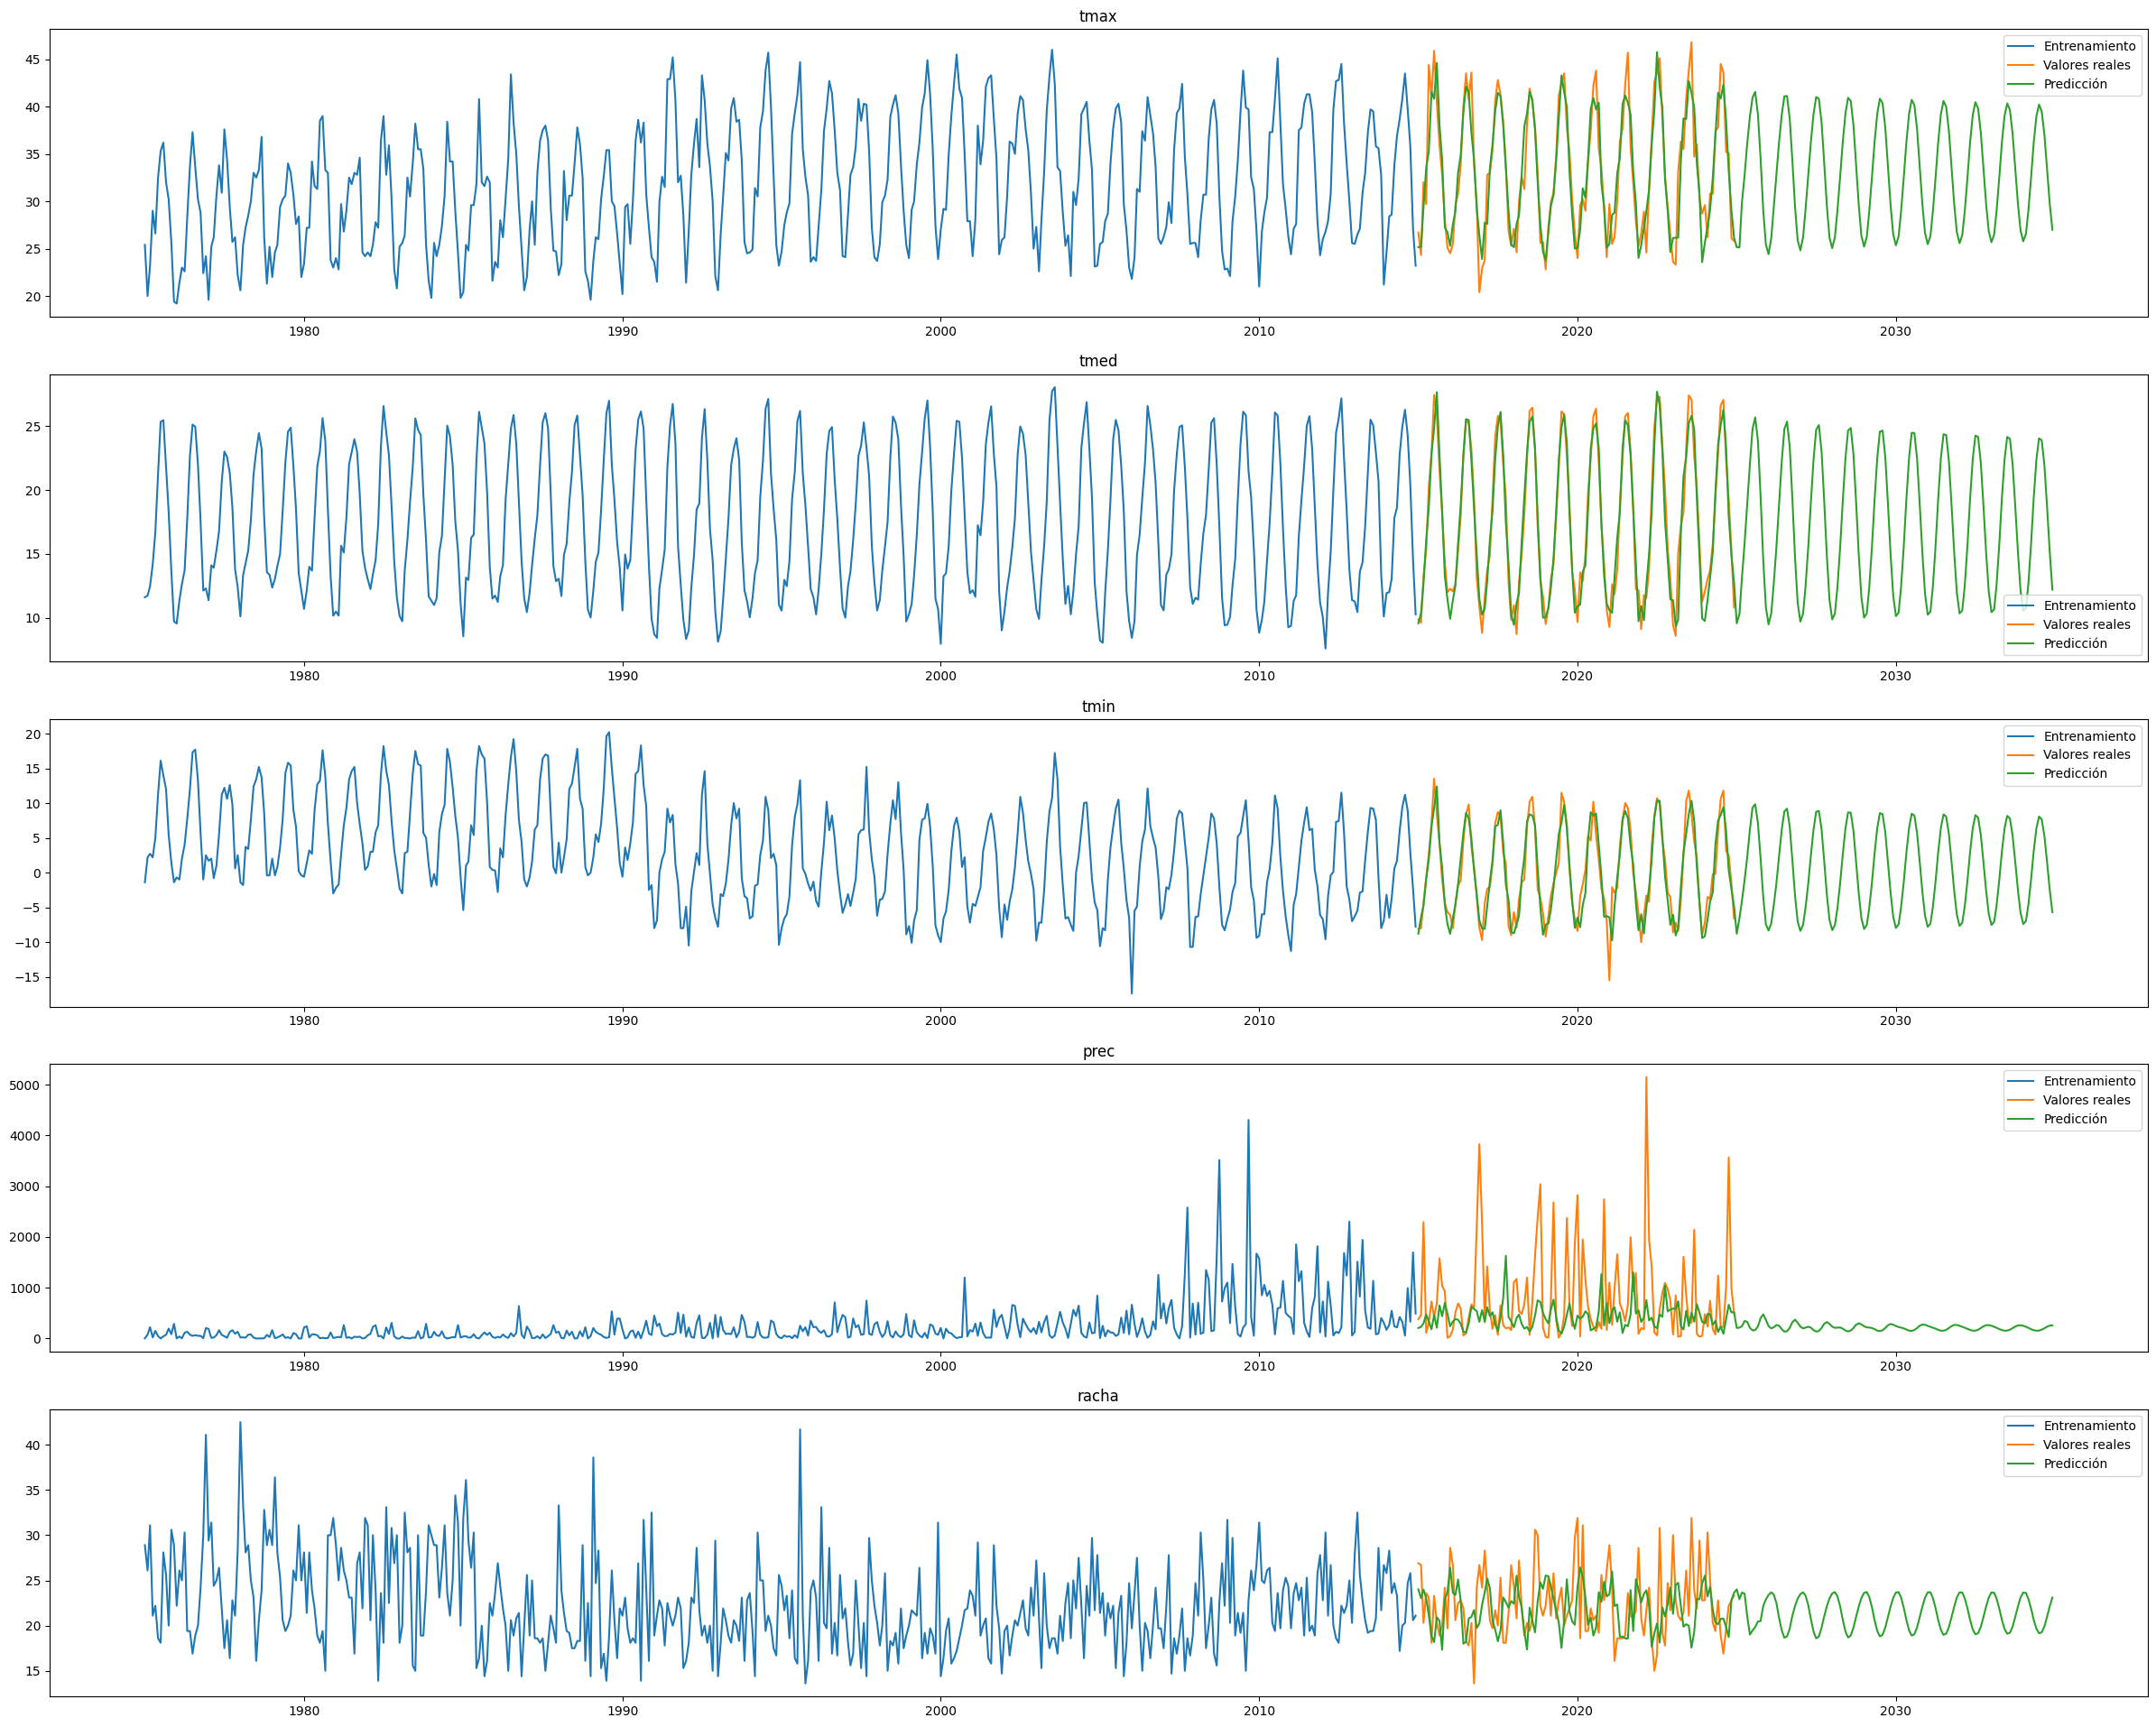

In [27]:
pintar_predicciones('VALENCIA', annos = 40)

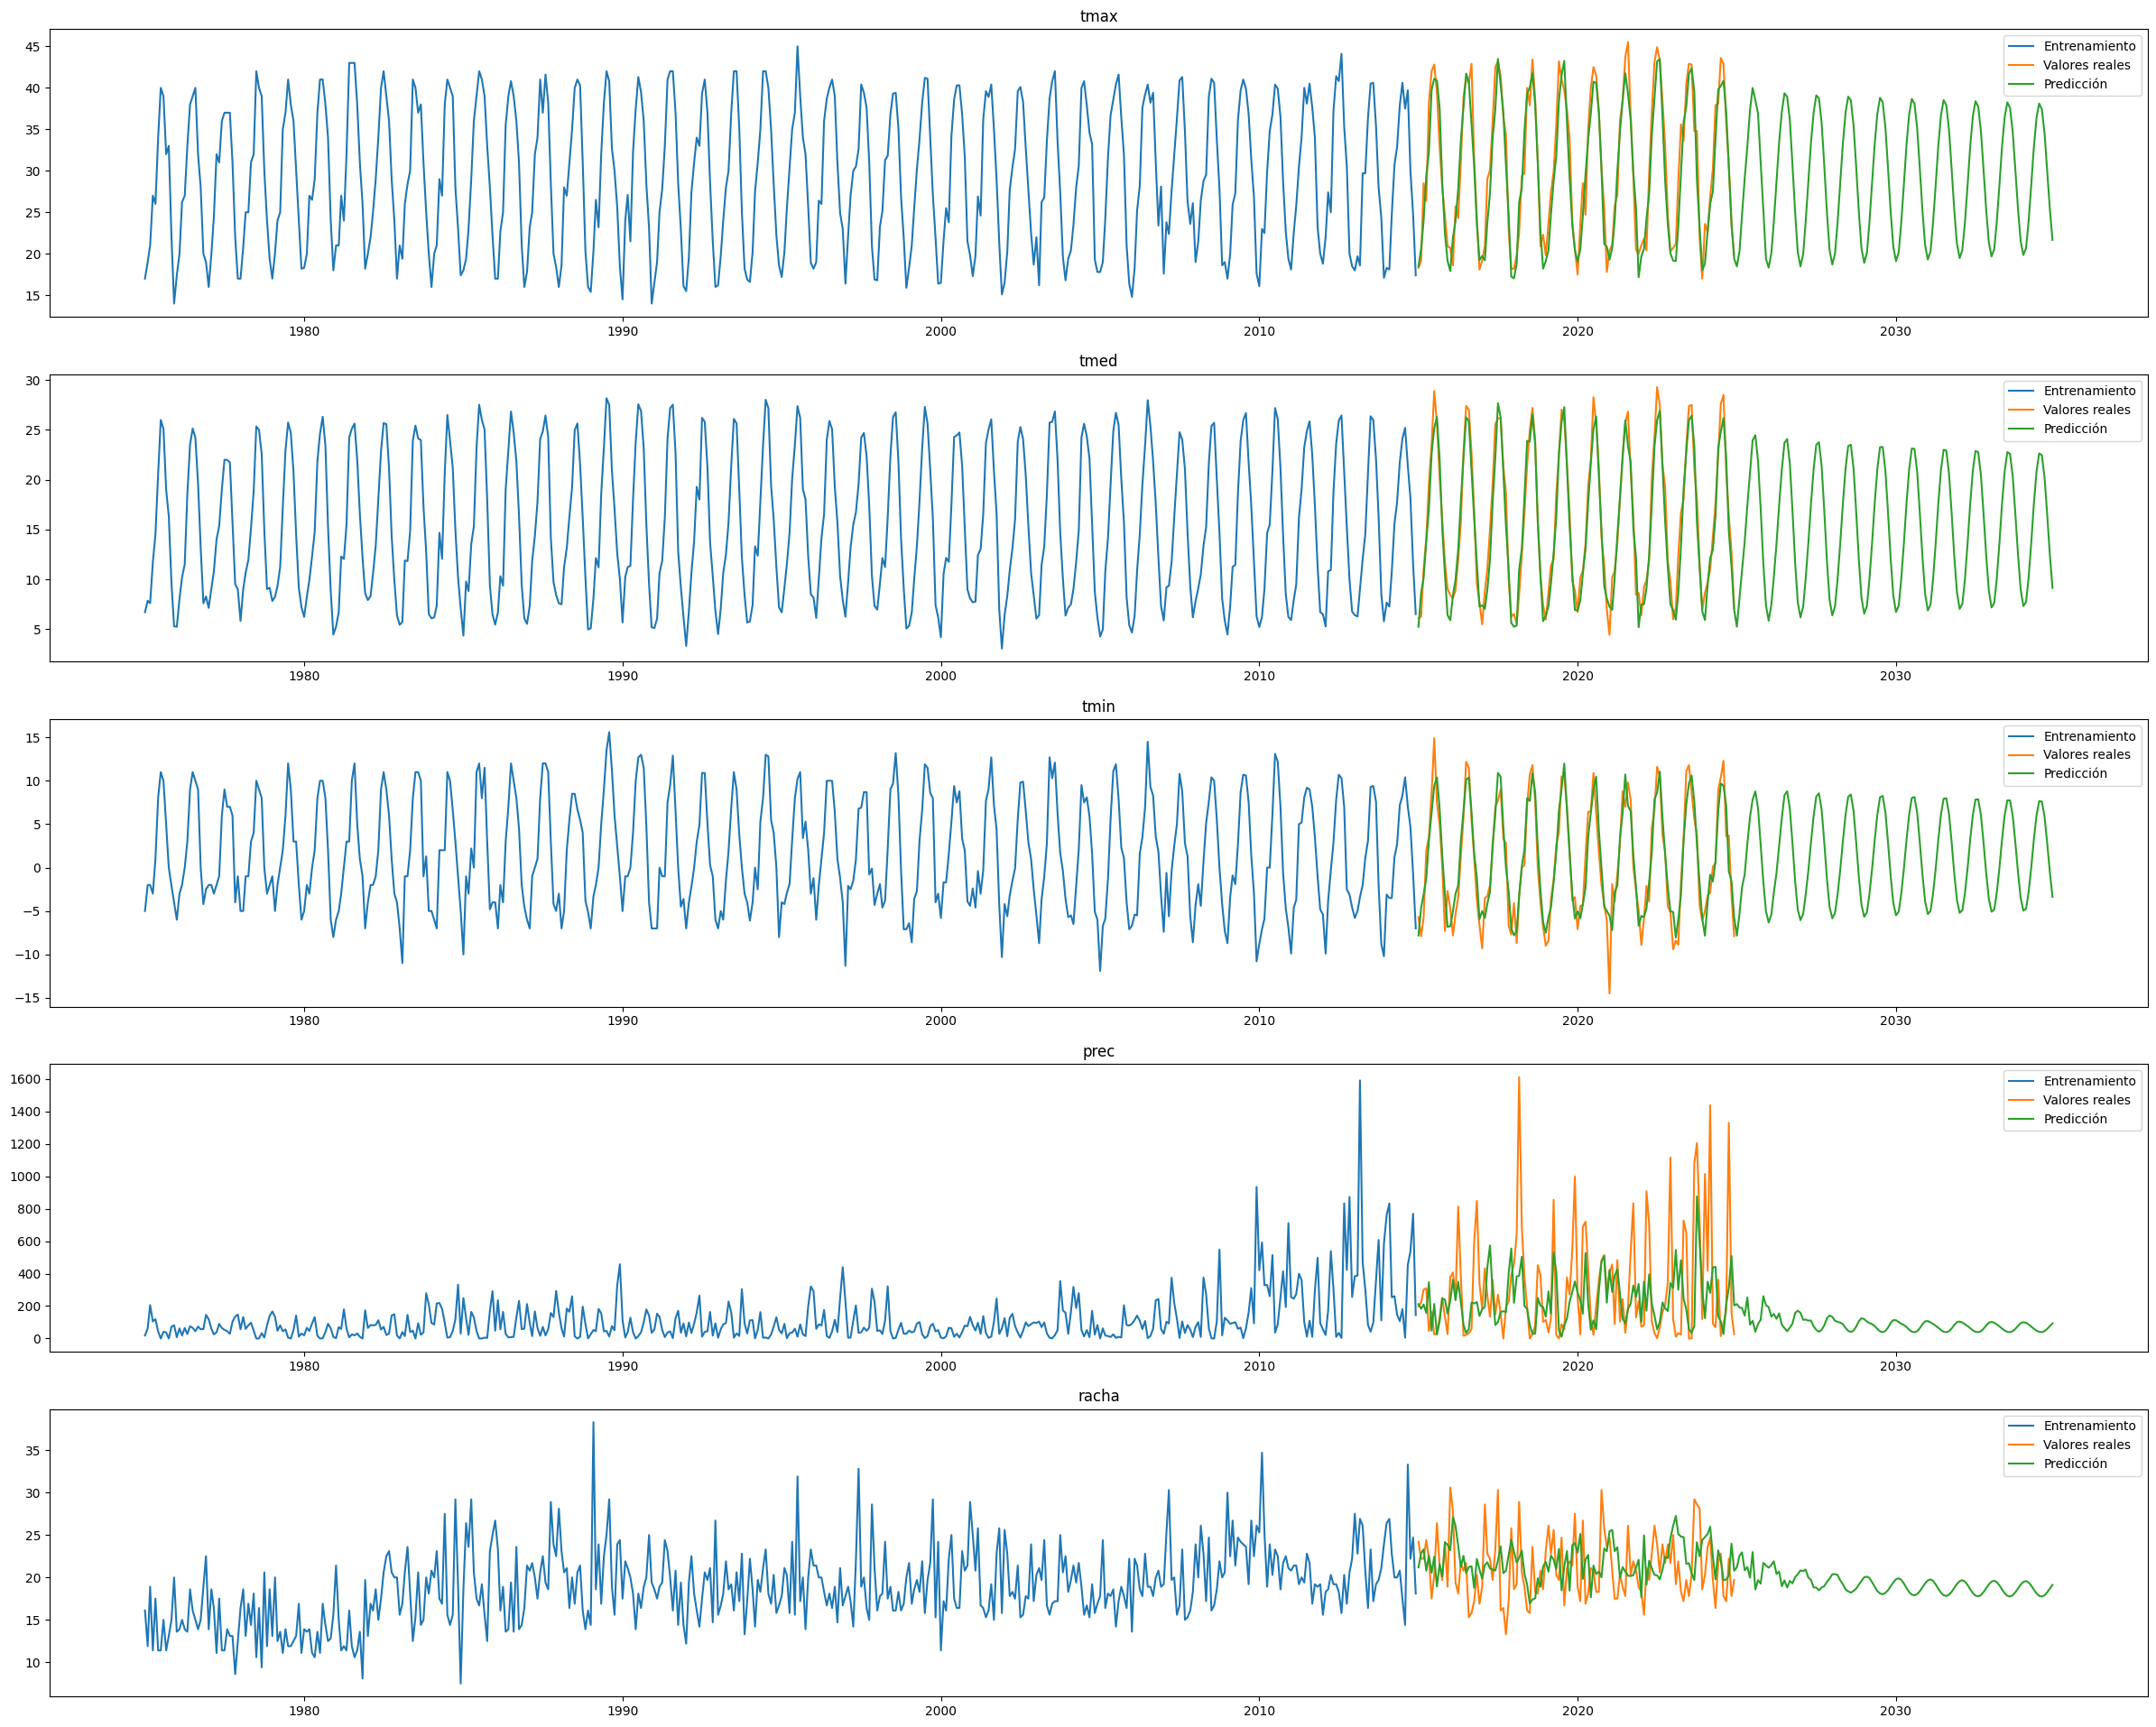

In [28]:
pintar_predicciones('TOLEDO', annos = 40)